# Pipeline Prediksi Log Return Kurs USD/IDR dengan Sentimen Berita (Labelling + Fitur Baseline)

Feature engineering **hanya yang ada di notebook baseline** (`baseline_kurs_tengah.ipynb`), tidak ada tambahan:
`kurs_lag1`-`kurs_lag5`, `kurs_roll_mean5`, `kurs_roll_std5` (dari Kurs Tengah). Selebihnya fitur model adalah hasil
data labelling (VADER dan Loughran-McDonald) yang diagregasi per hari trading, apa adanya. Tidak ada fitur waktu,
fitur jumlah berita, lag/rolling/diff pada label, maupun TF-IDF/SVD.

Urutan pipeline:
1. Preprocessing (berita & kurs)
2. Data labelling: **VADER** dan **Loughran-McDonald (LM)**
3. Penyelarasan berita ke hari trading + agregasi harian + merge dengan kurs + target + fitur time-series baseline
4. Split kronologis **70 / 15 / 15**
5. Dataset final (fitur baseline + kolom hasil labelling)
6. Normalisasi (StandardScaler, **fit di train saja**) + training semua model regresi dengan **parameter default**
7. Ablation study antar metode labelling (MAE, MSE, RMSE, DirAcc)
8. Feature selection top-K dan perbandingannya


# 1. Preprocessing

In [1]:
import re
import html
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import nltk
from langdetect import detect, DetectorFactory, LangDetectException

DetectorFactory.seed = 42
warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)

In [2]:
news_raw = pd.read_csv('data/raw/cnbc_with_published.csv')
bi_raw = pd.read_csv('data/raw/bi-usd-rate.csv')

print("Berita geopolitik :", news_raw.shape)
print("Kurs USD BI       :", bi_raw.shape)
news_raw.head(5)


Berita geopolitik : (16733, 13)
Kurs USD BI       : (1202, 5)


,keyword_matched,title,url,preview_summary,full_text,date_raw,section,published_raw,published_date,published_time,published_timezone,published_iso,scrape_status
0,geopolitical risk,Global shipping authorities warn of maritime trade breakdown amidgeopoliticalturmoil,https://www.cnbc.com/2026/09/08/global-shipping-iran-war-hormuz-rules.html?&qsearchterm=geopolitical risk,Global maritime authorities have warned that the emergence of “parallel systems” threatens to create a two-tier stru...,"Global maritime authorities have warned that the emergence of ""parallel systems"" threatens to create a two-tier stru...",9/8/2026 2:28:41 PM,Markets,2026-09-08T07:28:41+0000,2026-09-08,07:28 AM,0.0,2026-09-08T07:28:41+0000,ok
1,geopolitical risk,Morning Call Sheet: AI rebound meets risinggeopoliticalrisks,https://www.cnbc.com/video/2026/07/31/morning-call-sheet-ai-rebound-meets-rising-geopolitical-risks.html?&qsearchter...,"Peter Tchir, Head of Macro Strategy at Academy Securities, Thomas Martin, Senior Portfolio Manager at GLOBALT Invest...",NaN,7/31/2026 5:58:53 PM,Morning Call,NaN,NaN,NaN,NaN,NaN,not_found
2,geopolitical risk,"Global markets keep shrugging off shocks. Here’s what could break that streak, according to HSBC",https://www.cnbc.com/2026/09/08/global-markets-shrug-off-shocks-hsbc-sees-what-could-break-the-streak.html?&qsearcht...,"Global markets have shrugged off a barrage of shocks in recent years, but HSBC sees several developments that could ...","In this article Global markets have shrugged off a barrage of shocks in recent years, but HSBC sees several developm...",9/8/2026 11:02:43 AM,World Markets,2026-09-08T04:02:43+0000,2026-09-08,04:02 AM,0.0,2026-09-08T04:02:43+0000,ok
3,geopolitical risk,"Yen hovers near seven-month high, dollar steadies",https://www.cnbc.com/2026/09/08/yen-extends-rally-to-new-seven-month-high-dollar-subdued-ahead-of-cpi.html?&qsearcht...,"The Japanese yen hovered near ​a seven-month high on Tuesday, while the dollar was little changed against major peer...","In this article The Japanese yen hovered near ​a seven-month high on Tuesday, while the dollar was little changed ag...",9/8/2026 11:17:07 AM,Currencies,2026-09-08T04:17:07+0000,2026-09-08,04:17 AM,0.0,2026-09-08T04:17:07+0000,ok
4,geopolitical risk,Central banks are bringing gold reserves home asgeopoliticalrisks rise,https://www.cnbc.com/2026/06/17/central-banks-gold-reserves-domestic-storage.html?&qsearchterm=geopolitical risk,"More and more central banks are storing gold bullion at home rather than overseas, as they expect to buy more of the...","In this article More and more central banks are storing gold bullion at home rather than overseas, as they expect to...",6/17/2026 2:28:36 PM,Gold,2026-06-17T07:28:36+0000,2026-06-17,07:28 AM,0.0,2026-06-17T07:28:36+0000,ok


In [3]:
news_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16733 entries, 0 to 16732
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   keyword_matched     16733 non-null  object 
 1   title               16733 non-null  object 
 2   url                 16733 non-null  object 
 3   preview_summary     16733 non-null  object 
 4   full_text           13431 non-null  object 
 5   date_raw            16733 non-null  object 
 6   section             16649 non-null  object 
 7   published_raw       15239 non-null  object 
 8   published_date      15239 non-null  object 
 9   published_time      15239 non-null  object 
 10  published_timezone  15239 non-null  float64
 11  published_iso       15239 non-null  object 
 12  scrape_status       16733 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.7+ MB


In [4]:
# Parse timestamp mentah GEO dan pisahkan tanggal & jam dengan timezone WIB.
news_raw["date_raw_dt"] = pd.to_datetime(news_raw["date_raw"], errors="coerce")
news_raw["date_raw_dt_wib"] = (
    pd.to_datetime(news_raw["date_raw_dt"], errors="coerce", utc=True)
    .dt.tz_convert("Asia/Jakarta")
    .dt.tz_localize(None)
)
news_raw["tanggal"] = news_raw["date_raw_dt_wib"].dt.strftime("%m/%d/%Y")
news_raw["jam"] = news_raw["date_raw_dt_wib"].dt.strftime("%I:%M %p")
news_raw = news_raw.drop(columns=["date_raw"], errors="ignore")

print("Kolom Berita Geopolitik:")
news_raw[["title", "tanggal", "jam", "date_raw_dt_wib"]].head(5)


Kolom Berita Geopolitik:


,title,tanggal,jam,date_raw_dt_wib
0,Global shipping authorities warn of maritime trade breakdown amidgeopoliticalturmoil,09/08/2026,09:28 PM,2026-09-08 21:28:41
1,Morning Call Sheet: AI rebound meets risinggeopoliticalrisks,08/01/2026,12:58 AM,2026-08-01 00:58:53
2,"Global markets keep shrugging off shocks. Here’s what could break that streak, according to HSBC",09/08/2026,06:02 PM,2026-09-08 18:02:43
3,"Yen hovers near seven-month high, dollar steadies",09/08/2026,06:17 PM,2026-09-08 18:17:07
4,Central banks are bringing gold reserves home asgeopoliticalrisks rise,06/17/2026,09:28 PM,2026-06-17 21:28:36


In [5]:
bi_raw["Tanggal_dt"] = pd.to_datetime(bi_raw["Tanggal"], errors="coerce")
bi_raw["tanggal"] = bi_raw["Tanggal_dt"].dt.strftime("%m/%d/%Y")
bi_raw["jam"] = bi_raw["Tanggal_dt"].dt.strftime("%I:%M %p")
bi_raw = bi_raw.drop(
    columns=["Tanggal"],
    errors="ignore"
)

print("Kolom Kurs BI:")
bi_raw.head(5)

Kolom Kurs BI:


,NO,Nilai,Kurs Jual,Kurs Beli,Tanggal_dt,tanggal,jam
0,1,1,17834.73,17657.27,2026-09-01,09/01/2026,12:00 AM
1,2,1,17791.51,17614.49,2026-08-31,08/31/2026,12:00 AM
2,3,1,17850.81,17673.19,2026-08-28,08/28/2026,12:00 AM
3,4,1,17805.58,17628.42,2026-08-27,08/27/2026,12:00 AM
4,5,1,17791.51,17614.49,2026-08-26,08/26/2026,12:00 AM


## 1.1 Cleaning berita

In [6]:
#delete duplicate rows
def word_count(text):
    if not isinstance(text, str):
        return 0
    return len(text.split())

news = news_raw.copy()
# Ukuran data awal
print(f"Baris awal                         : {len(news_raw)}")

# Filter rentang tanggal inklusif: 1 September 2021 - 1 September 2026
start_date = pd.Timestamp("2021-09-01")
end_date = pd.Timestamp("2026-09-01 23:59:59")
news = news[news["date_raw_dt"].between(start_date, end_date, inclusive="both")]
print(f"Setelah filter rentang 1 September 2021 - 1 September 2026 : {len(news)}")

# Setelah di drop URL
news = news.drop_duplicates(subset=["url"], keep="first")
print(f"Setelah dedup url                  : {len(news)}")

# Setelah di drop title + date_raw
news = news.drop_duplicates(subset=["title", "tanggal", "jam"], keep="first")
print(f"Setelah dedup title+date_raw       : {len(news)}")

Baris awal                         : 16733
Setelah filter rentang 1 September 2021 - 1 September 2026 : 8871
Setelah dedup url                  : 8871
Setelah dedup title+date_raw       : 7084


In [7]:
# Filter full_text yang kosong

# Buang baris yang tidak memiliki isi teks pada ketiga sumber konten.
text_columns = ["title", "preview_summary", "full_text"]
text_content = news[text_columns].fillna("").astype(str).agg(" ".join, axis=1).str.strip()
mask_empty = text_content.eq("")
news = news.loc[~mask_empty].copy()
print(f"Setelah drop teks kosong             : {len(news)}")

# Buang item multimedia berdasarkan URL, judul, dan section.
non_article_pattern = r"\b(video|videos|image|images|photo|photos|foto|gambar|audio|podcast|gallery|galeri|live)\b|\.(mp4|mov|avi|mp3|wav|jpg|jpeg|png)(?:$|[?#])"
content_metadata = news[["url", "title", "section"]].fillna("").astype(str).agg(" ".join, axis=1)
mask_non_article = content_metadata.str.contains(non_article_pattern, case=False, regex=True, na=False)
news = news.loc[~mask_non_article].copy()
print(f"Setelah drop video/gambar/audio      : {len(news)}")

news.head(5)

Setelah drop teks kosong             : 7084
Setelah drop video/gambar/audio      : 6214


,keyword_matched,title,url,preview_summary,full_text,section,published_raw,published_date,published_time,published_timezone,published_iso,scrape_status,date_raw_dt,date_raw_dt_wib,tanggal,jam
4,geopolitical risk,Central banks are bringing gold reserves home asgeopoliticalrisks rise,https://www.cnbc.com/2026/06/17/central-banks-gold-reserves-domestic-storage.html?&qsearchterm=geopolitical risk,"More and more central banks are storing gold bullion at home rather than overseas, as they expect to buy more of the...","In this article More and more central banks are storing gold bullion at home rather than overseas, as they expect to...",Gold,2026-06-17T07:28:36+0000,2026-06-17,07:28 AM,0.0,2026-06-17T07:28:36+0000,ok,2026-06-17 14:28:36,2026-06-17 21:28:36,06/17/2026,09:28 PM
8,geopolitical risk,Oil rises 2% as White House says no US-Iran talks happening,https://www.cnbc.com/2026/08/27/oil-prices-extend-losses-on-expectations-talks-to-ease-middle-east-supply-woes.html?...,"Oil prices rose Thursday, after Washington confirmed it was not in talks with ‌Iran despite diplomatic efforts by ot...","In this article Oil prices rose Thursday, after Washington confirmed it was not in talks with ‌Iran despite diplomat...",Oil,2026-08-27T02:49:03+0000,2026-08-27,02:49 AM,0.0,2026-08-27T02:49:03+0000,ok,2026-08-27 09:49:03,2026-08-27 16:49:03,08/27/2026,04:49 PM
9,geopolitical risk,Jamie Dimon says markets underestimate risks and he wouldn’t buy stocks or Treasurys at current ...,https://www.cnbc.com/2026/07/21/jpmorgan-chase-ceo-jamie-dimon-market-risk.html?&qsearchterm=geopolitical risk,JPMorgan Chase CEO Jamie Dimon said investors are underestimating the risks facing the global economy and that he wo...,In this article JPMorgan ChaseCEOJamie Dimonsaid investors are underestimating the risks facing the global economy a...,Finance,2026-07-20T23:01:01+0000,2026-07-20,11:01 PM,0.0,2026-07-20T23:01:01+0000,ok,2026-07-21 06:01:01,2026-07-21 13:01:01,07/21/2026,01:01 PM
13,geopolitical risk,"Citi Wealth warns markets may be ‘uncomfortably strong’ amid mountinggeopolitical, inflation risks",https://www.cnbc.com/2026/05/18/citi-wealth-warns-markets-may-be-uncomfortably-strong-as-risks-mount.html?&qsearchte...,"Global markets may be due for a period of consolidation after a sharp rally in equities, even as the longer-term out...",NaN,Pro: Analysis,2026-05-18T05:37:18+0000,2026-05-18,05:37 AM,0.0,2026-05-18T05:37:18+0000,ok,2026-05-18 12:37:18,2026-05-18 19:37:18,05/18/2026,07:37 PM
15,geopolitical risk,Where fixed income investors are finding yield asgeopoliticalriskrattles markets,https://www.cnbc.com/2026/04/10/where-fixed-income-investors-are-finding-yield-as-geopolitical-risk-rattles-markets....,"As the Iran war shakes up markets, strategists say there are still plenty of sources of relatively safe yield for in...",NaN,Pro: Income Investing,2026-04-10T19:25:17+0000,2026-04-10,07:25 PM,0.0,2026-04-10T19:25:17+0000,ok,2026-04-11 02:25:17,2026-04-11 09:25:17,04/11/2026,09:25 AM


In [8]:
# Panjang text minimal 350

effective_text = news["full_text"].fillna(news["preview_summary"])
news = news.loc[effective_text.apply(word_count) >= 350]
print(f"Setelah filter panjang teks min     : {len(news)}")

Setelah filter panjang teks min     : 4349


In [9]:
#Filter keyword yang relevan dengan geopolitik dan ekonomi
RELEVANCE_KEYWORDS = [
    "geopolitics",
    "geopolitical risk",
    "geopolitical tensions",
    "geopolitical fragmentation",
    "armed conflict",
    "global conflict",
    "international conflict",
    "military tensions",
    "national security",
    "sanctions",
    "trade war",
    "tariffs",
    "embargo",
    "export controls",
    "protectionism",
    "supply chain disruption",
    "diplomacy",
    "foreign policy",
    "nato",
    "brics",
    "opec",
    "g7",
]

EXCLUDE_SECTIONS = [
    "sports", "entertainment", "television", "lifestyle", "travel",
    "food retail", "beer, wine & spirits", "college", "modern medicine",
    "life changes", "fashion", "celebrity",
]

def is_relevant(row):
    """Berita dianggap relevan jika keyword_matched terisi ATAU teks memuat
    salah satu kata kunci geopolitik/ekonomi pada RELEVANCE_KEYWORDS."""
    if isinstance(row["keyword_matched"], str) and row["keyword_matched"].strip():
        return True
    haystack = f"{row.get('title', '')} {row.get('preview_summary', '')}".lower()
    return any(kw in haystack for kw in RELEVANCE_KEYWORDS)

mask_relevant = news.apply(is_relevant, axis=1)
news = news.loc[mask_relevant]

print(f"Setelah filter relevansi kata kunci : {len(news)}")

# 4.5 Filter kategori/section yang tidak relevan
section_lower = news["section"].fillna("").str.lower()
mask_section = ~section_lower.isin(EXCLUDE_SECTIONS)
news = news.loc[mask_section].reset_index(drop=True)

print(f"Setelah filter kategori/section     : {len(news)}")

news.head(3)


Setelah filter relevansi kata kunci : 4349
Setelah filter kategori/section     : 4336


,keyword_matched,title,url,preview_summary,full_text,section,published_raw,published_date,published_time,published_timezone,published_iso,scrape_status,date_raw_dt,date_raw_dt_wib,tanggal,jam
0,geopolitical risk,Central banks are bringing gold reserves home asgeopoliticalrisks rise,https://www.cnbc.com/2026/06/17/central-banks-gold-reserves-domestic-storage.html?&qsearchterm=geopolitical risk,"More and more central banks are storing gold bullion at home rather than overseas, as they expect to buy more of the...","In this article More and more central banks are storing gold bullion at home rather than overseas, as they expect to...",Gold,2026-06-17T07:28:36+0000,2026-06-17,07:28 AM,0.0,2026-06-17T07:28:36+0000,ok,2026-06-17 14:28:36,2026-06-17 21:28:36,06/17/2026,09:28 PM
1,geopolitical risk,Oil rises 2% as White House says no US-Iran talks happening,https://www.cnbc.com/2026/08/27/oil-prices-extend-losses-on-expectations-talks-to-ease-middle-east-supply-woes.html?...,"Oil prices rose Thursday, after Washington confirmed it was not in talks with ‌Iran despite diplomatic efforts by ot...","In this article Oil prices rose Thursday, after Washington confirmed it was not in talks with ‌Iran despite diplomat...",Oil,2026-08-27T02:49:03+0000,2026-08-27,02:49 AM,0.0,2026-08-27T02:49:03+0000,ok,2026-08-27 09:49:03,2026-08-27 16:49:03,08/27/2026,04:49 PM
2,geopolitical risk,Jamie Dimon says markets underestimate risks and he wouldn’t buy stocks or Treasurys at current ...,https://www.cnbc.com/2026/07/21/jpmorgan-chase-ceo-jamie-dimon-market-risk.html?&qsearchterm=geopolitical risk,JPMorgan Chase CEO Jamie Dimon said investors are underestimating the risks facing the global economy and that he wo...,In this article JPMorgan ChaseCEOJamie Dimonsaid investors are underestimating the risks facing the global economy a...,Finance,2026-07-20T23:01:01+0000,2026-07-20,11:01 PM,0.0,2026-07-20T23:01:01+0000,ok,2026-07-21 06:01:01,2026-07-21 13:01:01,07/21/2026,01:01 PM


In [10]:
# delete missing values
jumlah_nan = news["full_text"].isna().sum()

print("Jumlah full_text NaN:", jumlah_nan)

news_nan = news.loc[news["full_text"].isna()]

news_nan[
    ["url", "title", "preview_summary", "full_text"]
].head()

news = news.dropna(subset=["full_text"]).reset_index(drop=True)

print("Jumlah baris setelah drop NaN:", len(news))
print("Sisa NaN pada full_text:", news["full_text"].isna().sum())

Jumlah full_text NaN: 0
Jumlah baris setelah drop NaN: 4336
Sisa NaN pada full_text: 0


In [11]:
#menggabungkan title, preview, dan full_text

# Tidak ada nilai kosong yang mengganggu penggabungan teks.
news[["title", "preview_summary", "full_text"]] = (
    news[["title", "preview_summary", "full_text"]].fillna("")
)

# Gabungkan title + preview_summary + full_text.
news["combined_raw"] = (
    ((news["title"] + " ") * 2)
    + news["preview_summary"] + " "
    + news["full_text"]
)

print(f"Jumlah baris: {len(news)}")
news[["title", "combined_raw"]].head(3)

Jumlah baris: 4336


,title,combined_raw
0,Central banks are bringing gold reserves home asgeopoliticalrisks rise,Central banks are bringing gold reserves home asgeopoliticalrisks rise Central banks are bringing gold reserves home...
1,Oil rises 2% as White House says no US-Iran talks happening,Oil rises 2% as White House says no US-Iran talks happening Oil rises 2% as White House says no US-Iran talks happen...
2,Jamie Dimon says markets underestimate risks and he wouldn’t buy stocks or Treasurys at current ...,Jamie Dimon says markets underestimate risks and he wouldn’t buy stocks or Treasurys at current ... Jamie Dimon says...


In [12]:
import unicodedata
from collections import Counter

symbol_counter = Counter()
for text in news["combined_raw"]:
    for ch in text:
        if not (ch.isalnum() or ch.isspace()):
            symbol_counter[ch] += 1

symbol_df = pd.DataFrame(
    [
        (ch, unicodedata.name(ch, "UNKNOWN"), count)
        for ch, count in symbol_counter.most_common()
    ],
    columns=["simbol", "nama_unicode", "jumlah"],
)

print(f"Jumlah jenis simbol unik pada combined_raw: {len(symbol_df)}")
symbol_df

Jumlah jenis simbol unik pada combined_raw: 54


,simbol,nama_unicode,jumlah
0,.,FULL STOP,232989
1,",",COMMA,203423
2,"""",QUOTATION MARK,88912
3,',APOSTROPHE,60351
4,-,HYPHEN-MINUS,41818
5,%,PERCENT SIGN,18915
6,—,EM DASH,10379
7,$,DOLLAR SIGN,9806
8,’,RIGHT SINGLE QUOTATION MARK,6782
9,:,COLON,5100


In [13]:
#cleaning dari tanda baca yang tidak berguna

URL_RE = re.compile(r"http\S+|www\.\S+")
EMAIL_RE = re.compile(r"\S+@\S+\.\S+")
HTML_TAG_RE = re.compile(r"<[^>]+>")
EMOJI_RE = re.compile(
    "["
    "\U0001F300-\U0001FAFF"
    "\U00002700-\U000027BF"
    "\U0001F1E6-\U0001F1FF"
    "\U00002600-\U000026FF"
    "]+",
    flags=re.UNICODE,
)

# Hanya simbol mata uang yang diubah jadi kata.
# Simbol lain (&, +, tanda baca umum) dibuang di NON_ALNUM_RE.
CURRENCY_WORDS = {
    "%": "percent",
    "$": "dollar",
    "£": "pound",
    "€": "euro",
    "¥": "yen",
}
CURRENCY_RE = re.compile("|".join(re.escape(sym) for sym in CURRENCY_WORDS))
NON_ALNUM_RE = re.compile(r"[^a-zA-Z0-9\s]")  # simbol/tanda baca sisa dibuang; huruf & angka dipertahankan
MULTI_SPACE_RE = re.compile(r"\s+")


def normalize_text(text: str) -> str:
    """Hapus HTML/URL/email/emoji, ubah simbol mata uang jadi kata, angka dipertahankan."""
    if not isinstance(text, str) or not text.strip():
        return ""
    t = html.unescape(text)
    t = HTML_TAG_RE.sub(" ", t)
    t = URL_RE.sub(" ", t)
    t = EMAIL_RE.sub(" ", t)
    t = EMOJI_RE.sub(" ", t)
    t = CURRENCY_RE.sub(lambda m: f" {CURRENCY_WORDS[m.group(0)]} ", t)
    t = NON_ALNUM_RE.sub(" ", t)
    t = MULTI_SPACE_RE.sub(" ", t).strip()
    return t


news["normalized_text"] = news["combined_raw"].apply(normalize_text)

news[["combined_raw", "normalized_text"]].head(3)

,combined_raw,normalized_text
0,Central banks are bringing gold reserves home asgeopoliticalrisks rise Central banks are bringing gold reserves home...,Central banks are bringing gold reserves home asgeopoliticalrisks rise Central banks are bringing gold reserves home...
1,Oil rises 2% as White House says no US-Iran talks happening Oil rises 2% as White House says no US-Iran talks happen...,Oil rises 2 percent as White House says no US Iran talks happening Oil rises 2 percent as White House says no US Ira...
2,Jamie Dimon says markets underestimate risks and he wouldn’t buy stocks or Treasurys at current ... Jamie Dimon says...,Jamie Dimon says markets underestimate risks and he wouldn t buy stocks or Treasurys at current Jamie Dimon says mar...


In [14]:
# lowercasing
news["lower_text"] = news["normalized_text"].str.lower()

news[["normalized_text", "lower_text"]].head(3)

,normalized_text,lower_text
0,Central banks are bringing gold reserves home asgeopoliticalrisks rise Central banks are bringing gold reserves home...,central banks are bringing gold reserves home asgeopoliticalrisks rise central banks are bringing gold reserves home...
1,Oil rises 2 percent as White House says no US Iran talks happening Oil rises 2 percent as White House says no US Ira...,oil rises 2 percent as white house says no us iran talks happening oil rises 2 percent as white house says no us ira...
2,Jamie Dimon says markets underestimate risks and he wouldn t buy stocks or Treasurys at current Jamie Dimon says mar...,jamie dimon says markets underestimate risks and he wouldn t buy stocks or treasurys at current jamie dimon says mar...


In [15]:
#memastikan bahasanya english semua
def detect_language(text: str) -> str:
    if not isinstance(text, str) or len(text.strip()) < 20:
        return "unknown"
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"


news["detected_lang"] = news["lower_text"].apply(detect_language)

print("Distribusi bahasa terdeteksi:")
print(news["detected_lang"].value_counts().head(10))

baris_sebelum = len(news)
news = news.loc[news["detected_lang"] == "en"].reset_index(drop=True)
print(f"\nSetelah filter bahasa Inggris (en) : {len(news)} (dibuang {baris_sebelum - len(news)} baris)")

news[["lower_text", "detected_lang"]].head(3)

Distribusi bahasa terdeteksi:
detected_lang
en    4336
Name: count, dtype: int64

Setelah filter bahasa Inggris (en) : 4336 (dibuang 0 baris)


,lower_text,detected_lang
0,central banks are bringing gold reserves home asgeopoliticalrisks rise central banks are bringing gold reserves home...,en
1,oil rises 2 percent as white house says no us iran talks happening oil rises 2 percent as white house says no us ira...,en
2,jamie dimon says markets underestimate risks and he wouldn t buy stocks or treasurys at current jamie dimon says mar...,en


## 1.2 Cleaning data kurs

In [16]:
# Gabungkan tanggal dan jam untuk satu kolom datetime kanonik.
bi_raw["Tanggal"] = pd.to_datetime(
    bi_raw["tanggal"].astype(str).str.strip() + " " + bi_raw["jam"].astype(str).str.strip(),
    format="%m/%d/%Y %I:%M %p",
    errors="coerce",
)

print(bi_raw.shape)
bi_raw.head(3)

(1202, 8)


,NO,Nilai,Kurs Jual,Kurs Beli,Tanggal_dt,tanggal,jam,Tanggal
0,1,1,17834.73,17657.27,2026-09-01,09/01/2026,12:00 AM,2026-09-01
1,2,1,17791.51,17614.49,2026-08-31,08/31/2026,12:00 AM,2026-08-31
2,3,1,17850.81,17673.19,2026-08-28,08/28/2026,12:00 AM,2026-08-28


In [17]:
def clean_numeric(series: pd.Series) -> pd.Series:
    """Hapus pemisah ribuan dan konversi nilai ke float."""
    cleaned = series.astype(str).str.replace(",", "", regex=False).str.strip()
    return pd.to_numeric(cleaned, errors="coerce")



bi_raw["Kurs Jual"] = clean_numeric(bi_raw["Kurs Jual"])
bi_raw["Kurs Beli"] = clean_numeric(bi_raw["Kurs Beli"])
bi_raw["NO"] = pd.to_numeric(bi_raw["NO"], errors="coerce")
bi_raw["Nilai"] = pd.to_numeric(bi_raw["Nilai"], errors="coerce")

print(f"Baris awal BI                 : {len(bi_raw)}")

# Pertahankan hanya rentang 1 September 2021 sampai 1 September 2026.
bi = bi_raw.loc[bi_raw["Tanggal"].between(start_date, end_date, inclusive="both")]
print(f"Setelah filter rentang tanggal: {len(bi)}")

mask_valid_numeric = (
    bi["Kurs Jual"].notna()
    & bi["Kurs Beli"].notna()
    & (bi["Kurs Jual"] > 0)
    & (bi["Kurs Beli"] > 0)
)
bi = bi.loc[mask_valid_numeric]
print(f"Setelah filter numerik valid  : {len(bi)}")

mask_valid_spread = bi["Kurs Jual"] > bi["Kurs Beli"]
bi = bi.loc[mask_valid_spread]
print(f"Setelah filter Jual > Beli    : {len(bi)}")

bi = (
    bi.sort_values("Tanggal")
    .drop_duplicates(subset=["Tanggal"], keep="last")
    .reset_index(drop=True)
)
print(f"Setelah dedup tanggal         : {len(bi)}")

bi.head(3)

Baris awal BI                 : 1202
Setelah filter rentang tanggal: 1202
Setelah filter numerik valid  : 1202
Setelah filter Jual > Beli    : 1202
Setelah dedup tanggal         : 1202


,NO,Nilai,Kurs Jual,Kurs Beli,Tanggal_dt,tanggal,jam,Tanggal
0,1202,1,14377.53,14234.47,2021-09-01,09/01/2021,12:00 AM,2021-09-01
1,1201,1,14355.42,14212.58,2021-09-02,09/02/2021,12:00 AM,2021-09-02
2,1200,1,14352.41,14209.60,2021-09-03,09/03/2021,12:00 AM,2021-09-03


# 2. Data Labelling (VADER & LM)

## 2.1 VADER

In [18]:
USE_VADER = True   # <- True = aktif, False = nonaktif (kolom VADER dibuang dari news)

# Hitung VADER tiap judul (per artikel, teks mentah tanpa tokenisasi/lowercase/lemmatisasi)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon', quiet=True)
vader = SentimentIntensityAnalyzer()

def score_title(t):
    # judul kosong jangan dihitung sebagai 0 (netral), biarkan NaN
    if isinstance(t, str) and t.strip():
        return vader.polarity_scores(t)['compound']
    return np.nan

news = news.drop(columns=['vader_title'], errors='ignore')   # bersihkan sisa run sebelumnya

if USE_VADER:
    news['vader_title'] = news['title'].apply(score_title)
    print('VADER aktif')
    display(news[['title', 'vader_title']].head())
else:
    print('VADER dinonaktifkan')

VADER aktif


,title,vader_title
0,Central banks are bringing gold reserves home asgeopoliticalrisks rise,0.0000
1,Oil rises 2% as White House says no US-Iran talks happening,-0.2960
2,Jamie Dimon says markets underestimate risks and he wouldn’t buy stocks or Treasurys at current ...,-0.5106
3,China’s super-rich fled Singapore. Now they want to come back,0.0772
4,‘Don’t get too comfortable’: Wall Street’s ‘fear gauge’ hits 2026 low — here’s why it’s ...,-0.2732


## 2.2 Loughran-McDonald

In [21]:
# ===== LOUGHRAN-McDONALD: muat kamus & fungsi skor (jalankan sekali) =====
# Kategori LM yang dipakai. Boleh ditambah: 'constraining', 'strong_modal', 'weak_modal'.
# 'negative' dan 'positive' wajib ada (dipakai untuk skor net = positive - negative).
import glob

LM_CATS = ['negative', 'positive', 'uncertainty', 'litigious']

LM_COLS = {'negative': 'Negative', 'positive': 'Positive', 'uncertainty': 'Uncertainty',
           'litigious': 'Litigious', 'constraining': 'Constraining',
           'strong_modal': 'Strong_Modal', 'weak_modal': 'Weak_Modal'}
assert {'negative', 'positive'} <= set(LM_CATS), "LM_CATS harus memuat 'negative' dan 'positive'"

# Kamus resmi: Loughran-McDonald Master Dictionary 1993-2025 (sraf.nd.edu), letakkan di data/lexicon/
lm_files = glob.glob('data/raw/Loughran-McDonald_MasterDictionary_1993-2025.csv')
LM_FILE = Path('data/raw/Loughran-McDonald_MasterDictionary_1993-2025.csv')
if not lm_files:
    raise FileNotFoundError("Taruh Loughran-McDonald_MasterDictionary_1993-2025.csv di data/lexicon/")
lm_path = lm_files[-1]

lm_df = pd.read_csv(lm_path, usecols=['Word'] + [LM_COLS[c] for c in LM_CATS])
lm_df = lm_df.dropna(subset=['Word'])                       # buang baris tanpa kata
lm_df['Word'] = lm_df['Word'].astype(str).str.lower()
LM_SETS = {c: set(lm_df.loc[lm_df[LM_COLS[c]] > 0, 'Word']) for c in LM_CATS}
print(f"Kamus LM dari: {lm_path}")
print({c: len(s) for c, s in LM_SETS.items()})

WORD_RE = re.compile(r'[a-z]+')

def lm_scores(text):
    """Proporsi kata tiap kategori LM terhadap total kata (text harus sudah lowercase)."""
    tokens = WORD_RE.findall(text) if isinstance(text, str) else []
    n = len(tokens)
    if n == 0:
        return [np.nan] * len(LM_CATS)            # teks kosong -> NaN, bukan 0
    return [sum(t in LM_SETS[c] for t in tokens) / n for c in LM_CATS]

Kamus LM dari: data/raw/Loughran-McDonald_MasterDictionary_1993-2025.csv
{'negative': 2345, 'positive': 347, 'uncertainty': 297, 'litigious': 903}


In [22]:
USE_LM_TITLE = True   # <- True = aktif, False = nonaktif (kolom lm_title_* dibuang dari news)

news = news.drop(columns=[c for c in news.columns if c.startswith('lm_title_')])   # bersihkan sisa run sebelumnya

if USE_LM_TITLE:
    assert LM_SETS is not None, 'Kamus LM belum termuat (lihat cell setup LM di atas)'
    scores = news['title'].apply(lambda t: lm_scores(normalize_text(t).lower())).tolist()
    lm_t = pd.DataFrame(scores, columns=[f'lm_title_{c}' for c in LM_CATS], index=news.index)
    lm_t['lm_title_net'] = lm_t['lm_title_positive'] - lm_t['lm_title_negative']
    for col in lm_t.columns:
        news[col] = lm_t[col].values
    print('LM judul aktif')
    display(news[['title'] + list(lm_t.columns)].head())
else:
    print('LM judul dinonaktifkan')

LM judul aktif


,title,lm_title_negative,lm_title_positive,lm_title_uncertainty,lm_title_litigious,lm_title_net
0,Central banks are bringing gold reserves home asgeopoliticalrisks rise,0.000000,0.0,0.0000,0.0,0.000000
1,Oil rises 2% as White House says no US-Iran talks happening,0.000000,0.0,0.0000,0.0,0.000000
2,Jamie Dimon says markets underestimate risks and he wouldn’t buy stocks or Treasurys at current ...,0.062500,0.0,0.0625,0.0,-0.062500
3,China’s super-rich fled Singapore. Now they want to come back,0.000000,0.0,0.0000,0.0,0.000000
4,‘Don’t get too comfortable’: Wall Street’s ‘fear gauge’ hits 2026 low — here’s why it’s ...,0.058824,0.0,0.0000,0.0,-0.058824


In [23]:
USE_LM_TEXT = True   # <- True = aktif, False = nonaktif (kolom lm_text_* dibuang dari news)

news = news.drop(columns=[c for c in news.columns if c.startswith('lm_text_')])   # bersihkan sisa run sebelumnya

if USE_LM_TEXT:
    assert LM_SETS is not None, 'Kamus LM belum termuat (lihat cell setup LM di atas)'
    # isi berita (full_text) dinormalisasi seperti pipeline lain, lalu lowercase.
    # Tanpa stopword removal/lemmatisasi: kamus LM sudah memuat bentuk turunan kata.
    scores = news['full_text'].apply(lambda t: lm_scores(normalize_text(t).lower())).tolist()
    lm_x = pd.DataFrame(scores, columns=[f'lm_text_{c}' for c in LM_CATS], index=news.index)
    lm_x['lm_text_net'] = lm_x['lm_text_positive'] - lm_x['lm_text_negative']
    for col in lm_x.columns:
        news[col] = lm_x[col].values
    print('LM isi aktif')
    display(news[list(lm_x.columns)].describe().T)
else:
    print('LM isi dinonaktifkan')

LM isi aktif


,count,mean,std,min,25%,50%,75%,max
lm_text_negative,4336.0,0.022886,0.010348,0.000000,0.015212,0.022095,0.029216,0.069705
lm_text_positive,4336.0,0.007593,0.005135,0.000000,0.003952,0.006706,0.010245,0.042959
lm_text_uncertainty,4336.0,0.009784,0.006003,0.000000,0.005413,0.008674,0.013118,0.042017
lm_text_litigious,4336.0,0.002639,0.005038,0.000000,0.000000,0.001311,0.002980,0.081146
lm_text_net,4336.0,-0.015292,0.012596,-0.067024,-0.023056,-0.014851,-0.006957,0.041766


# 3. Penyelarasan, Agregasi Harian, Target & Fitur Baseline

## 3.1 Penyelarasan berita ke hari trading

In [24]:
#change timezone to WIB
news['published_raw'] = pd.to_datetime(news['published_raw'], errors='coerce', utc=True)
news['published_raw'] = news['published_raw'].dt.tz_convert('Asia/Jakarta')

#pisahin tanggal & waktu
news['date'] = news['published_raw'].dt.date
news['time'] = news['published_raw'].dt.time

In [25]:
def align_to_trading_date(dt):
    # Step 1: kalau lewat cutoff 15:00:00, geser ke hari berikutnya
    cutoff = dt.replace(hour=15, minute=0, second=0, microsecond=0)
    if dt > cutoff:
        dt = dt + pd.Timedelta(days=1)

    # Step 2: kalau hasilnya jatuh di weekend, geser ke Senin
    if dt.weekday() == 5:      # Sabtu
        dt = dt + pd.Timedelta(days=2)
    elif dt.weekday() == 6:    # Minggu
        dt = dt + pd.Timedelta(days=1)

    return dt.normalize()  # buang jam, sisakan tanggal saja

news['aligned_trading_date'] = news['date_raw_dt'].apply(align_to_trading_date)

In [26]:
# Snap ke hari trading yang ada di data kurs (jalankan SETELAH cell align_to_trading_date di atas)
td = pd.DatetimeIndex(bi_raw['Tanggal_dt']).normalize().unique().sort_values()   # hari trading yang ada di data kurs
ad = pd.DatetimeIndex(news['aligned_trading_date'])

pos = td.searchsorted(ad, side='left')       # hari trading pertama yang >= tanggal hasil alignment
ok = pos < len(td)                           # artikel setelah hari kurs terakhir tidak punya tujuan
print(f"Artikel dibuang karena melewati hari kurs terakhir: {(~ok).sum()}")

news = news.loc[ok].copy()
news['aligned_trading_date'] = td[pos[ok]]

Artikel dibuang karena melewati hari kurs terakhir: 3


## 3.2 Agregasi harian & merge dengan kurs

In [27]:
# urutkan dulu supaya urutan artikel konsisten
news_sorted = news.sort_values('date_raw_dt')

# news_count hanya untuk referensi (membedakan hari tanpa berita), BUKAN fitur model
agg_spec = {'news_count': ('title', 'size')}

# statistik VADER untuk 1 tanggal aligned
if 'vader_title' in news_sorted.columns:
    agg_spec.update({
        'vader_title_mean':      ('vader_title', 'mean'),
        'vader_title_min':       ('vader_title', 'min'),
        'vader_title_max':       ('vader_title', 'max'),
        'vader_title_std':       ('vader_title', 'std'),
        'vader_title_pos_ratio': ('vader_title', lambda x: (x.dropna() > 0.05).mean()),   # ambang standar VADER
        'vader_title_neg_ratio': ('vader_title', lambda x: (x.dropna() < -0.05).mean()),
    })

# LM (judul/isi): rata-rata harian dari skor per artikel (hanya kolom yang aktif)
sent_cols = [c for c in news_sorted.columns if c.startswith(('lm_title_', 'lm_text_'))]
for c in sent_cols:
    agg_spec[c] = (c, 'mean')

daily_news = (
    news_sorted.groupby('aligned_trading_date')
               .agg(**agg_spec)
               .reset_index()
)

# 1 artikel saja -> std NaN, ganti 0
if 'vader_title_std' in daily_news.columns:
    daily_news['vader_title_std'] = daily_news['vader_title_std'].fillna(0.0)

daily_news

,aligned_trading_date,news_count,vader_title_mean,vader_title_min,vader_title_max,vader_title_std,vader_title_pos_ratio,vader_title_neg_ratio,lm_title_negative,lm_title_positive,lm_title_uncertainty,lm_title_litigious,lm_title_net,lm_text_negative,lm_text_positive,lm_text_uncertainty,lm_text_litigious,lm_text_net
0,2021-09-06,1,-0.318200,-0.3182,-0.3182,0.000000,0.000000,1.000000,0.076923,0.000000,0.076923,0.0,-0.076923,0.023179,0.003311,0.019868,0.000000,-0.019868
1,2021-09-08,1,-0.340000,-0.3400,-0.3400,0.000000,0.000000,1.000000,0.000000,0.000000,0.090909,0.0,0.000000,0.046174,0.011873,0.014512,0.003958,-0.034301
2,2021-09-09,1,0.077200,0.0772,0.0772,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.026696,0.003337,0.011123,0.003337,-0.023359
3,2021-09-10,1,-0.571900,-0.5719,-0.5719,0.000000,0.000000,1.000000,0.071429,0.000000,0.000000,0.0,-0.071429,0.016393,0.005464,0.000000,0.001821,-0.010929
4,2021-09-13,4,-0.200950,-0.4019,0.0000,0.232037,0.000000,0.500000,0.016667,0.000000,0.000000,0.0,-0.016667,0.025949,0.007085,0.007313,0.004650,-0.018863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062,2026-08-26,4,0.130800,-0.2732,0.7964,0.462045,0.250000,0.250000,0.000000,0.016667,0.000000,0.0,0.016667,0.029517,0.004789,0.010258,0.000909,-0.024728
1063,2026-08-27,1,-0.296000,-0.2960,-0.2960,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.022599,0.013183,0.020716,0.000000,-0.009416
1064,2026-08-28,6,-0.051617,-0.7269,0.3400,0.356078,0.333333,0.166667,0.053419,0.000000,0.000000,0.0,-0.053419,0.020352,0.006506,0.009552,0.002654,-0.013845
1065,2026-08-31,7,-0.354814,-0.7506,0.0000,0.308026,0.000000,0.857143,0.051941,0.000000,0.000000,0.0,-0.051941,0.026656,0.004853,0.004582,0.002785,-0.021803


In [28]:
# 1. Samakan tipe & buang jam di kedua kunci
bi_raw['Tanggal_dt'] = pd.to_datetime(bi_raw['Tanggal_dt']).dt.normalize()
daily_news['aligned_trading_date'] = pd.to_datetime(daily_news['aligned_trading_date']).dt.normalize()

# 2. Cek duplikat kunci (kalau ada, baris akan membengkak setelah merge)
print(bi_raw['Tanggal_dt'].duplicated().sum())
print(daily_news['aligned_trading_date'].duplicated().sum())

# 3. Merge
merged_data = pd.merge(
    bi_raw,
    daily_news,
    left_on='Tanggal_dt',
    right_on='aligned_trading_date',
    how='left',
    validate='one_to_one'   # error kalau ada duplikat, jadi ketahuan
).drop(columns='aligned_trading_date')

# 4. Hari tanpa berita: news_count = 0 dan skor sentimen netral (0.0)
merged_data['news_count'] = merged_data['news_count'].fillna(0).astype(int)
sent_cols = [c for c in merged_data.columns if c.startswith(('vader_title_', 'lm_title_', 'lm_text_'))]
merged_data[sent_cols] = merged_data[sent_cols].fillna(0.0)

merged_data

0
0


,NO,Nilai,Kurs Jual,Kurs Beli,Tanggal_dt,tanggal,jam,Tanggal,news_count,vader_title_mean,...,lm_title_negative,lm_title_positive,lm_title_uncertainty,lm_title_litigious,lm_title_net,lm_text_negative,lm_text_positive,lm_text_uncertainty,lm_text_litigious,lm_text_net
0,1,1,17834.73,17657.27,2026-09-01,09/01/2026,12:00 AM,2026-09-01,1,-0.726900,...,0.083333,0.000000,0.083333,0.0,-0.083333,0.028302,0.009434,0.007075,0.002358,-0.018868
1,2,1,17791.51,17614.49,2026-08-31,08/31/2026,12:00 AM,2026-08-31,7,-0.354814,...,0.051941,0.000000,0.000000,0.0,-0.051941,0.026656,0.004853,0.004582,0.002785,-0.021803
2,3,1,17850.81,17673.19,2026-08-28,08/28/2026,12:00 AM,2026-08-28,6,-0.051617,...,0.053419,0.000000,0.000000,0.0,-0.053419,0.020352,0.006506,0.009552,0.002654,-0.013845
3,4,1,17805.58,17628.42,2026-08-27,08/27/2026,12:00 AM,2026-08-27,1,-0.296000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.022599,0.013183,0.020716,0.000000,-0.009416
4,5,1,17791.51,17614.49,2026-08-26,08/26/2026,12:00 AM,2026-08-26,4,0.130800,...,0.000000,0.016667,0.000000,0.0,0.016667,0.029517,0.004789,0.010258,0.000909,-0.024728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1197,1198,1,14310.20,14167.81,2021-09-07,09/07/2021,12:00 AM,2021-09-07,0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1198,1199,1,14332.31,14189.70,2021-09-06,09/06/2021,12:00 AM,2021-09-06,1,-0.318200,...,0.076923,0.000000,0.076923,0.0,-0.076923,0.023179,0.003311,0.019868,0.000000,-0.019868
1199,1200,1,14352.41,14209.60,2021-09-03,09/03/2021,12:00 AM,2021-09-03,0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1200,1201,1,14355.42,14212.58,2021-09-02,09/02/2021,12:00 AM,2021-09-02,0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [29]:
# Simpan hanya kolom yang dibutuhkan: kurs (untuk target), news_count (referensi), dan kolom hasil labelling
label_cols_all = [c for c in merged_data.columns if c.startswith(('vader_title_', 'lm_title_', 'lm_text_'))]
merged_data_clean = merged_data[['Tanggal_dt', 'Kurs Jual', 'Kurs Beli', 'news_count'] + label_cols_all].copy()
merged_data_clean

,Tanggal_dt,Kurs Jual,Kurs Beli,news_count,vader_title_mean,vader_title_min,vader_title_max,vader_title_std,vader_title_pos_ratio,vader_title_neg_ratio,lm_title_negative,lm_title_positive,lm_title_uncertainty,lm_title_litigious,lm_title_net,lm_text_negative,lm_text_positive,lm_text_uncertainty,lm_text_litigious,lm_text_net
0,2026-09-01,17834.73,17657.27,1,-0.726900,-0.7269,-0.7269,0.000000,0.000000,1.000000,0.083333,0.000000,0.083333,0.0,-0.083333,0.028302,0.009434,0.007075,0.002358,-0.018868
1,2026-08-31,17791.51,17614.49,7,-0.354814,-0.7506,0.0000,0.308026,0.000000,0.857143,0.051941,0.000000,0.000000,0.0,-0.051941,0.026656,0.004853,0.004582,0.002785,-0.021803
2,2026-08-28,17850.81,17673.19,6,-0.051617,-0.7269,0.3400,0.356078,0.333333,0.166667,0.053419,0.000000,0.000000,0.0,-0.053419,0.020352,0.006506,0.009552,0.002654,-0.013845
3,2026-08-27,17805.58,17628.42,1,-0.296000,-0.2960,-0.2960,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.022599,0.013183,0.020716,0.000000,-0.009416
4,2026-08-26,17791.51,17614.49,4,0.130800,-0.2732,0.7964,0.462045,0.250000,0.250000,0.000000,0.016667,0.000000,0.0,0.016667,0.029517,0.004789,0.010258,0.000909,-0.024728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1197,2021-09-07,14310.20,14167.81,0,0.000000,0.0000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1198,2021-09-06,14332.31,14189.70,1,-0.318200,-0.3182,-0.3182,0.000000,0.000000,1.000000,0.076923,0.000000,0.076923,0.0,-0.076923,0.023179,0.003311,0.019868,0.000000,-0.019868
1199,2021-09-03,14352.41,14209.60,0,0.000000,0.0000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1200,2021-09-02,14355.42,14212.58,0,0.000000,0.0000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 3.3 Target & fitur time-series (identik dengan baseline)
Fitur kurs hanya yang ada di `baseline_kurs_tengah.ipynb`: 5 lag Kurs Tengah, serta rata-rata dan std rolling 5 hari
yang dihitung dari `shift(1)` (persis definisi baseline). Fitur hasil labelling dipakai apa adanya (tanpa lag, rolling, atau diff).
Target = log return hari trading berikutnya (t -> t+1). `ret` hanya kolom referensi untuk baseline naive "Return kemarin", bukan fitur.


In [30]:
d = merged_data_clean.sort_values('Tanggal_dt', ascending=True).reset_index(drop=True)

# --- Kurs Tengah, target, dan kolom referensi ---
d['kurs_mid'] = (d['Kurs Jual'] + d['Kurs Beli']) / 2      # = "Kurs Tengah" di baseline
log_mid = np.log(d['kurs_mid'])
d['ret'] = log_mid.diff()              # referensi untuk baseline naive, BUKAN fitur
d['target'] = d['ret'].shift(-1)       # log return hari berikutnya (t -> t+1)

# --- Fitur time-series: HANYA yang ada di baseline ---
for lag in range(1, 6):
    d[f'kurs_lag{lag}'] = d['kurs_mid'].shift(lag)
# rolling mean & std 5 hari dari shift(1), supaya tidak memakai kurs hari yang sama (sama dengan baseline)
d['kurs_roll_mean5'] = d['kurs_mid'].shift(1).rolling(5).mean()
d['kurs_roll_std5']  = d['kurs_mid'].shift(1).rolling(5).std()

feat_ts = ['kurs_lag1', 'kurs_lag2', 'kurs_lag3', 'kurs_lag4', 'kurs_lag5',
           'kurs_roll_mean5', 'kurs_roll_std5']

# --- Fitur hasil labelling apa adanya, dikelompokkan per metode ---
LABEL_GROUPS = {
    'VADER':    [c for c in d.columns if c.startswith('vader_')],
    'LM judul': [c for c in d.columns if c.startswith('lm_title_')],
    'LM isi':   [c for c in d.columns if c.startswith('lm_text_')],
}
LABEL_GROUPS = {g: cols for g, cols in LABEL_GROUPS.items() if cols}
feat_label = [c for cols in LABEL_GROUPS.values() for c in cols]

# Buang baris awal (lag/rolling belum lengkap) dan baris terakhir (target NaN), SEBELUM split
merged_data_clean = d.dropna(subset=['ret', 'target'] + feat_ts + feat_label).reset_index(drop=True)

print(merged_data_clean.shape)
print({'Kurs (baseline)': len(feat_ts), **{g: len(c) for g, c in LABEL_GROUPS.items()}},
      '| total fitur:', len(feat_ts) + len(feat_label))
merged_data_clean[['Tanggal_dt', 'kurs_mid', 'ret', 'target'] + feat_ts[:3]].head()

(1196, 30)
{'Kurs (baseline)': 7, 'VADER': 6, 'LM judul': 5, 'LM isi': 5} | total fitur: 23


,Tanggal_dt,kurs_mid,ret,target,kurs_lag1,kurs_lag2,kurs_lag3
0,2021-09-08,14195.005,-0.003095,0.004989,14239.005,14261.005,14281.005
1,2021-09-09,14266.000,0.004989,0.000420,14195.005,14239.005,14261.005
2,2021-09-10,14272.000,0.000420,-0.003298,14266.000,14195.005,14239.005
3,2021-09-13,14225.005,-0.003298,0.002457,14272.000,14266.000,14195.005
4,2021-09-14,14260.000,0.002457,-0.000210,14225.005,14272.000,14266.000


# 4. Split Data (70 / 15 / 15, kronologis)

In [31]:
merged_data_clean = merged_data_clean.sort_values('Tanggal_dt', ascending=True).reset_index(drop=True)

n = len(merged_data_clean)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train = merged_data_clean.iloc[:train_end].copy()
val   = merged_data_clean.iloc[train_end:val_end].copy()
test  = merged_data_clean.iloc[val_end:].copy()

# buang 1 baris terakhir di train & val: target baris itu (t+1) adalah hari pertama set berikutnya
train = train.iloc[:-1].copy()
val   = val.iloc[:-1].copy()

assert train['Tanggal_dt'].max() < val['Tanggal_dt'].min() < test['Tanggal_dt'].min()

tot = len(train) + len(val) + len(test)
for name, d_ in [('Train', train), ('Val', val), ('Test', test)]:
    print(f"{name:5}: {len(d_):5d} ({len(d_) / tot:.1%}) | {d_['Tanggal_dt'].min().date()} -> {d_['Tanggal_dt'].max().date()}")

Train:   836 (70.0%) | 2021-09-08 -> 2025-02-18
Val  :   178 (14.9%) | 2025-02-20 -> 2025-11-20
Test :   180 (15.1%) | 2025-11-24 -> 2026-08-31


# 5. Dataset Final (fitur baseline + hasil labelling)

In [32]:
# ===== DATAFRAME FINAL: fitur baseline + kolom hasil labelling + target (+ referensi kurs_mid, ret) =====
final_cols = ['Tanggal_dt', 'kurs_mid', 'ret'] + feat_ts + feat_label + ['target']

final_train = train[final_cols].reset_index(drop=True)
final_val   = val[final_cols].reset_index(drop=True)
final_test  = test[final_cols].reset_index(drop=True)

for name, d_ in [('Train', final_train), ('Val', final_val), ('Test', final_test)]:
    assert d_.isna().sum().sum() == 0, f'{name} masih ada NaN'
    print(f"{name:5}: {d_.shape}")

# peta fitur -> grup (dipakai untuk ringkasan komposisi fitur)
GROUP_OF = {c: 'Kurs' for c in feat_ts}
GROUP_OF.update({c: g for g, cols in LABEL_GROUPS.items() for c in cols})

# simpan
Path('data/processed').mkdir(parents=True, exist_ok=True)
for name, d_ in [('train', final_train), ('val', final_val), ('test', final_test)]:
    d_.to_csv(f'data/processed/{name}.csv', index=False, date_format='%Y-%m-%d')

Train: (836, 27)
Val  : (178, 27)
Test : (180, 27)


# 6. Setup Modelling
- Normalisasi: `StandardScaler` di-fit **hanya di train** untuk tiap set fitur, lalu dipakai untuk val/test.
- Semua model memakai **parameter default** library (tanpa tuning). `random_state` hanya untuk reproduksibilitas.
- Metrik: MAE, MSE, RMSE, DirAcc (arah naik/turun benar, baris dengan target tepat 0 tidak dihitung).
- `PredStd` ≈ 0 berarti model menghasilkan prediksi konstan (umum pada Lasso/ElasticNet/SVR default karena target sangat kecil).

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                              AdaBoostRegressor, GradientBoostingRegressor)

pd.set_option('display.float_format', lambda x: f'{x:.6g}')
SEED = 42

# Semua model regresi: PARAMETER DEFAULT (tanpa tuning)
MODELS = {
    'LinearRegression': lambda: LinearRegression(),
    'Ridge':            lambda: Ridge(),
    'Lasso':            lambda: Lasso(),
    'ElasticNet':       lambda: ElasticNet(),
    'BayesianRidge':    lambda: BayesianRidge(),
    'KNN':              lambda: KNeighborsRegressor(),
    'SVR':              lambda: SVR(),
    'DecisionTree':     lambda: DecisionTreeRegressor(random_state=SEED),
    'RandomForest':     lambda: RandomForestRegressor(random_state=SEED, n_jobs=-1),
    'ExtraTrees':       lambda: ExtraTreesRegressor(random_state=SEED, n_jobs=-1),
    'AdaBoost':         lambda: AdaBoostRegressor(random_state=SEED),
    'GradientBoosting': lambda: GradientBoostingRegressor(random_state=SEED),
}
try:
    from xgboost import XGBRegressor
    MODELS['XGBoost'] = lambda: XGBRegressor(random_state=SEED, n_jobs=-1, verbosity=0)
except ImportError:
    print('xgboost tidak terpasang -> dilewati')
try:
    from lightgbm import LGBMRegressor
    MODELS['LightGBM'] = lambda: LGBMRegressor(random_state=SEED, n_jobs=-1, verbosity=-1)
except ImportError:
    print('lightgbm tidak terpasang -> dilewati')

METRICS = ['MAE', 'MSE', 'RMSE', 'DirAcc']

def evaluate(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    mse = mean_squared_error(y_true, y_pred)
    nz = y_true != 0                                   # arah tidak terdefinisi kalau target tepat 0
    dir_acc = np.mean(np.sign(y_pred[nz]) == np.sign(y_true[nz])) if nz.any() else np.nan
    return {'MAE': mean_absolute_error(y_true, y_pred), 'MSE': mse, 'RMSE': np.sqrt(mse), 'DirAcc': dir_acc}

y_tr, y_va, y_te = final_train['target'], final_val['target'], final_test['target']

def prepare(cols):
    """Normalisasi: scaler di-fit HANYA di train, lalu diterapkan ke val & test."""
    scaler = StandardScaler().fit(final_train[cols])
    return (scaler.transform(final_train[cols]),
            scaler.transform(final_val[cols]),
            scaler.transform(final_test[cols]))

def fit_eval(make_model, X_tr, X_va, X_te):
    """Latih model (parameter default) di train, evaluasi di val & test."""
    model = make_model().fit(X_tr, y_tr)
    out = {}
    for split, X, y in (('Val', X_va, y_va), ('Test', X_te, y_te)):
        p = model.predict(X)
        out[split] = {**evaluate(y, p), 'PredStd': float(np.std(p))}
    return out

# Pembanding naive (tanpa model)
naive = pd.DataFrame([
    {'Baseline': 'Prediksi 0', 'Split': s, **evaluate(y, np.zeros(len(y)))}
    for s, y in (('Val', y_va), ('Test', y_te))
] + [
    {'Baseline': 'Return kemarin', 'Split': s, **evaluate(y, df_['ret'])}
    for s, y, df_ in (('Val', y_va, final_val), ('Test', y_te, final_test))
])
print(f"{len(MODELS)} model: {list(MODELS)}")
naive

14 model: ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet', 'BayesianRidge', 'KNN', 'SVR', 'DecisionTree', 'RandomForest', 'ExtraTrees', 'AdaBoost', 'GradientBoosting', 'XGBoost', 'LightGBM']


,Baseline,Split,MAE,MSE,RMSE,DirAcc
0,Prediksi 0,Val,0.00246991,1.14367e-05,0.00338182,0
1,Prediksi 0,Test,0.00220518,8.45542e-06,0.00290782,0
2,Return kemarin,Val,0.00346751,2.12584e-05,0.00461068,0.505682
3,Return kemarin,Test,0.00308416,1.58166e-05,0.00397701,0.545455


# 7. Ablation Study (metode labelling)
Dasar fitur yang selalu ada: **fitur time-series baseline** (`kurs_lag1`-`kurs_lag5`, `kurs_roll_mean5`, `kurs_roll_std5`).
Yang berganti hanya metode labelling (VADER, LM judul, LM isi): tanpa labelling -> 1 label -> 2 label -> semua label.


In [34]:
from itertools import combinations

base_feats = feat_ts

# set fitur ablation: {nama: (tahap, daftar kolom)}
ablation_sets = {'Tanpa labelling': ('0 label', base_feats)}
label_names = list(LABEL_GROUPS)
for r in sorted({1, 2, len(label_names)}):
    if r > len(label_names):
        continue
    stage = 'Semua label' if r == len(label_names) else f'{r} label'
    for combo in combinations(label_names, r):
        ablation_sets[' + '.join(combo)] = (stage, base_feats + [c for g in combo for c in LABEL_GROUPS[g]])

rows = []
for fs_name, (stage, cols) in ablation_sets.items():
    X_tr, X_va, X_te = prepare(cols)
    for m_name, make_model in MODELS.items():
        res = fit_eval(make_model, X_tr, X_va, X_te)
        for split in ('Val', 'Test'):
            rows.append({'Model': m_name, 'Set fitur': fs_name, 'Tahap': stage, 'n_fitur': len(cols),
                         'Split': split, **res[split]})
    print(f'selesai: {fs_name} ({len(cols)} fitur)')

results_ablation = pd.DataFrame(rows)
set_order = list(ablation_sets)
print(f"\n{len(ablation_sets)} set fitur x {len(MODELS)} model")

selesai: Tanpa labelling (7 fitur)
selesai: VADER (13 fitur)
selesai: LM judul (12 fitur)
selesai: LM isi (12 fitur)
selesai: VADER + LM judul (18 fitur)
selesai: VADER + LM isi (18 fitur)
selesai: LM judul + LM isi (17 fitur)
selesai: VADER + LM judul + LM isi (23 fitur)

8 set fitur x 14 model


In [35]:
# ===== Ringkasan ablation: rata-rata semua model per set fitur =====
summary_abl = (results_ablation.groupby(['Split', 'Set fitur'])[METRICS].mean()
               .reindex(pd.MultiIndex.from_product([['Val', 'Test'], set_order], names=['Split', 'Set fitur'])))
print('Rata-rata metrik semua model per set fitur (semua set memakai fitur time-series baseline):')
display(summary_abl)

# ===== Detail: tiap metrik, model x set fitur =====
for split in ('Val', 'Test'):
    for metric in METRICS:
        pv = (results_ablation[results_ablation['Split'] == split]
              .pivot(index='Model', columns='Set fitur', values=metric)[set_order]
              .reindex(list(MODELS)))
        print(f'\n=== {metric} | {split} ===')
        display(pv)

Rata-rata metrik semua model per set fitur (semua set memakai fitur time-series baseline):


MAE         MSE       RMSE   DirAcc
Split Set fitur                                                           
Val   Tanpa labelling           0.00272292 1.31602e-05 0.00361236 0.502029
      VADER                     0.00282431 1.42719e-05 0.00372906 0.465909
      LM judul                  0.00270435 1.31567e-05 0.00361414 0.501218
      LM isi                    0.00286845 1.44155e-05 0.00375316 0.480925
      VADER + LM judul          0.00277382 1.38342e-05 0.00369501 0.482143
      VADER + LM isi            0.00280486 1.40661e-05 0.00372362 0.476055
      LM judul + LM isi         0.00277922 1.37548e-05 0.00369316 0.478896
      VADER + LM judul + LM isi 0.00278822 1.40638e-05 0.00372985 0.483766
Test  Tanpa labelling            0.0024556 1.01535e-05 0.00316759 0.483766
      VADER                     0.00252412 1.11734e-05 0.00328845 0.522321
      LM judul                  0.00246711 1.02911e-05 0.00318004 0.487013
      LM isi                    0.00256135 1.11431e-05 0.00329762 0.478084
      VADER + LM judul          0.00255893 1.13301e-05 0.00331595 0.511364
      VADER + LM isi            0.00256411 1.14503e-05 0.00332969 0.505276
      LM judul + LM isi         0.00253585 1.09296e-05 0.00327216 0.472808
      VADER + LM judul + LM isi 0.00251714  1.0956e-05  0.0032798 0.519886


=== MAE | Val ===


Set fitur,Tanpa labelling,VADER,LM judul,LM isi,VADER + LM judul,VADER + LM isi,LM judul + LM isi,VADER + LM judul + LM isi
Model,,,,,,,,
LinearRegression,0.00252672,0.00262081,0.00254171,0.00257724,0.00263126,0.00266027,0.00258259,0.00266398
Ridge,0.00251092,0.00260342,0.002528,0.00256445,0.0026161,0.00264622,0.00256976,0.00265096
Lasso,0.00246464,0.00246464,0.00246464,0.00246464,0.00246464,0.00246464,0.00246464,0.00246464
ElasticNet,0.00246464,0.00246464,0.00246464,0.00246464,0.00246464,0.00246464,0.00246464,0.00246464
BayesianRidge,0.00250102,0.00254142,0.0025087,0.00254933,0.00254025,0.00257453,0.00255244,0.00257518
KNN,0.00284737,0.00264771,0.00261846,0.00302184,0.00269721,0.00272629,0.00285437,0.00278374
SVR,0.00310973,0.00310973,0.00310973,0.00310973,0.00310973,0.00310973,0.00310973,0.00310973
DecisionTree,0.00358013,0.00455825,0.0035398,0.00474399,0.00377004,0.00392404,0.00374971,0.00348397
RandomForest,0.00260867,0.00273018,0.00266523,0.00267383,0.00270002,0.00271443,0.0026882,0.00267258



=== MSE | Val ===


...

Set fitur,Tanpa labelling,VADER,LM judul,LM isi,VADER + LM judul,VADER + LM isi,LM judul + LM isi,VADER + LM judul + LM isi
Model,,,,,,,,
LinearRegression,8.96746e-06,8.58662e-06,8.93991e-06,8.88492e-06,8.52514e-06,8.59108e-06,8.89266e-06,8.55543e-06
Ridge,8.93223e-06,8.58095e-06,8.90443e-06,8.85293e-06,8.51749e-06,8.58775e-06,8.86151e-06,8.54992e-06
Lasso,8.37383e-06,8.37383e-06,8.37383e-06,8.37383e-06,8.37383e-06,8.37383e-06,8.37383e-06,8.37383e-06
ElasticNet,8.37383e-06,8.37383e-06,8.37383e-06,8.37383e-06,8.37383e-06,8.37383e-06,8.37383e-06,8.37383e-06
BayesianRidge,8.90476e-06,8.60181e-06,8.83556e-06,8.78216e-06,8.58721e-06,8.63751e-06,8.7894e-06,8.62984e-06
KNN,8.88419e-06,1.01291e-05,1.02054e-05,1.17824e-05,1.17073e-05,1.20694e-05,1.1582e-05,1.24887e-05
SVR,1.26194e-05,1.26194e-05,1.26194e-05,1.26194e-05,1.26194e-05,1.26194e-05,1.26194e-05,1.26194e-05
DecisionTree,1.75818e-05,2.83898e-05,2.06458e-05,2.45427e-05,2.70074e-05,2.83211e-05,2.28724e-05,2.15438e-05
RandomForest,9.02585e-06,1.08239e-05,9.18388e-06,9.58653e-06,1.01357e-05,1.03686e-05,9.21079e-06,1.02755e-05



=== RMSE | Test ===


Set fitur,Tanpa labelling,VADER,LM judul,LM isi,VADER + LM judul,VADER + LM isi,LM judul + LM isi,VADER + LM judul + LM isi
Model,,,,,,,,
LinearRegression,0.00299457,0.00293029,0.00298997,0.00298076,0.00291978,0.00293105,0.00298206,0.00292497
Ridge,0.00298868,0.00292933,0.00298403,0.00297539,0.00291847,0.00293049,0.00297683,0.00292402
Lasso,0.00289376,0.00289376,0.00289376,0.00289376,0.00289376,0.00289376,0.00289376,0.00289376
ElasticNet,0.00289376,0.00289376,0.00289376,0.00289376,0.00289376,0.00289376,0.00289376,0.00289376
BayesianRidge,0.00298408,0.00293288,0.00297247,0.00296347,0.00293039,0.00293896,0.00296469,0.00293766
KNN,0.00298064,0.00318262,0.00319459,0.00343256,0.00342159,0.00347411,0.00340323,0.00353394
SVR,0.00355238,0.00355238,0.00355238,0.00355238,0.00355238,0.00355238,0.00355238,0.00355238
DecisionTree,0.00419307,0.0053282,0.00454377,0.00495406,0.00519687,0.00532176,0.00478251,0.00464153
RandomForest,0.0030043,0.00328997,0.00303049,0.00309621,0.00318366,0.00322004,0.00303493,0.00320554



=== DirAcc | Test ===


Set fitur,Tanpa labelling,VADER,LM judul,LM isi,VADER + LM judul,VADER + LM isi,LM judul + LM isi,VADER + LM judul + LM isi
Model,,,,,,,,
LinearRegression,0.477273,0.573864,0.443182,0.443182,0.5625,0.551136,0.482955,0.585227
Ridge,0.4375,0.551136,0.448864,0.448864,0.556818,0.545455,0.471591,0.573864
Lasso,0.590909,0.590909,0.590909,0.590909,0.590909,0.590909,0.590909,0.590909
ElasticNet,0.590909,0.590909,0.590909,0.590909,0.590909,0.590909,0.590909,0.590909
BayesianRidge,0.414773,0.528409,0.397727,0.420455,0.505682,0.505682,0.443182,0.511364
KNN,0.528409,0.494318,0.454545,0.397727,0.426136,0.409091,0.426136,0.454545
SVR,0.590909,0.590909,0.590909,0.590909,0.590909,0.590909,0.590909,0.590909
DecisionTree,0.426136,0.465909,0.471591,0.5,0.460227,0.465909,0.4375,0.539773
RandomForest,0.420455,0.403409,0.431818,0.443182,0.420455,0.420455,0.420455,0.414773


In [36]:
# ===== Set fitur terbaik per model (dipilih dari RMSE VALIDATION; test hanya dilaporkan) =====
val_abl  = results_ablation[results_ablation['Split'] == 'Val']
test_abl = results_ablation[results_ablation['Split'] == 'Test'].set_index(['Model', 'Set fitur'])
best_idx = val_abl.loc[val_abl.groupby('Model')['RMSE'].idxmin()]

best_abl = best_idx.set_index('Model')[['Set fitur', 'n_fitur', 'RMSE']].rename(columns={'RMSE': 'Val RMSE'})
for metric in METRICS:
    best_abl[f'Test {metric}'] = [test_abl.loc[(m, s), metric] for m, s in zip(best_abl.index, best_abl['Set fitur'])]
best_abl = best_abl.reindex(list(MODELS)).sort_values('Val RMSE')
print('Set fitur terbaik per model:')
display(best_abl)

Set fitur terbaik per model:


,Set fitur,n_fitur,Val RMSE,Test MAE,Test MSE,Test RMSE,Test DirAcc
Model,,,,,,,
ElasticNet,Tanpa labelling,7,0.00337945,0.0021809,8.37383e-06,0.00289376,0.590909
Lasso,Tanpa labelling,7,0.00337945,0.0021809,8.37383e-06,0.00289376,0.590909
BayesianRidge,Tanpa labelling,7,0.00338869,0.00229396,8.90476e-06,0.00298408,0.414773
Ridge,LM judul,12,0.00339251,0.00229394,8.90443e-06,0.00298403,0.448864
LinearRegression,LM judul,12,0.00339944,0.00230087,8.93991e-06,0.00298997,0.443182
AdaBoost,Tanpa labelling,7,0.00344297,0.00234884,9.07439e-06,0.00301237,0.477273
KNN,VADER,13,0.00345167,0.00242964,1.01291e-05,0.00318262,0.494318
RandomForest,Tanpa labelling,7,0.00345949,0.00232296,9.02585e-06,0.0030043,0.420455
ExtraTrees,LM judul,12,0.00347102,0.0023158,8.84415e-06,0.00297391,0.443182


# 8. Feature Selection (top-10, top-15, top-20)
Untuk tiap model, kandidat fitur = **set fitur terbaik dari ablation** (menurut Val RMSE).
Ranking fitur = |korelasi Pearson| dengan target, dihitung di **train saja**. Setelah dipilih, fitur dinormalisasi (scaler fit di train), model dilatih ulang
(parameter default) lalu dievaluasi di val dan test. Hasilnya dibandingkan dengan model tanpa seleksi (semua fitur set terbaik).

In [37]:
TOP_KS = [10, 15, 20]
K_LABELS = [f'Top-{k}' for k in TOP_KS] + ['Semua fitur']

def composition(cols):
    cnt = pd.Series([GROUP_OF[c] for c in cols]).value_counts()
    return ' | '.join(f'{g} {n}' for g, n in cnt.items())

rows_fs = []
for m_name, make_model in MODELS.items():
    fs_name = best_abl.loc[m_name, 'Set fitur']
    pool = ablation_sets[fs_name][1]
    # ranking di TRAIN saja (val/test tidak dipakai); fitur konstan -> korelasi 0
    rank = final_train[pool].corrwith(y_tr).abs().fillna(0.0).sort_values(ascending=False).index.tolist()

    for k in TOP_KS:
        sel = rank[:min(k, len(pool))]
        X_tr, X_va, X_te = prepare(sel)
        res = fit_eval(make_model, X_tr, X_va, X_te)
        for split in ('Val', 'Test'):
            rows_fs.append({'Model': m_name, 'Set fitur': fs_name, 'K': f'Top-{k}', 'n_fitur': len(sel),
                            'Split': split, **res[split], 'Komposisi': composition(sel)})

    # pembanding: tanpa seleksi (hasil dari ablation)
    for split in ('Val', 'Test'):
        r = results_ablation[(results_ablation['Model'] == m_name) & (results_ablation['Set fitur'] == fs_name)
                             & (results_ablation['Split'] == split)].iloc[0]
        rows_fs.append({'Model': m_name, 'Set fitur': fs_name, 'K': 'Semua fitur', 'n_fitur': len(pool),
                        'Split': split, **{m: r[m] for m in METRICS}, 'PredStd': np.nan,
                        'Komposisi': composition(pool)})
    print('selesai:', m_name)

results_fs = pd.DataFrame(rows_fs)

selesai: LinearRegression
selesai: Ridge
selesai: Lasso
selesai: ElasticNet
selesai: BayesianRidge
selesai: KNN
selesai: SVR
selesai: DecisionTree
selesai: RandomForest
selesai: ExtraTrees
selesai: AdaBoost
selesai: GradientBoosting
selesai: XGBoost
selesai: LightGBM


In [38]:
# ===== Perbandingan K: tiap metrik, model x K =====
for split in ('Val', 'Test'):
    for metric in METRICS:
        pv = (results_fs[results_fs['Split'] == split]
              .pivot(index='Model', columns='K', values=metric)[K_LABELS]
              .reindex(list(MODELS)))
        print(f'\n=== {metric} | {split} ===')
        display(pv)


=== MAE | Val ===


K,Top-10,Top-15,Top-20,Semua fitur
Model,,,,
LinearRegression,0.00254171,0.00254171,0.00254171,0.00254171
Ridge,0.00252938,0.002528,0.002528,0.002528
Lasso,0.00246464,0.00246464,0.00246464,0.00246464
ElasticNet,0.00246464,0.00246464,0.00246464,0.00246464
BayesianRidge,0.00250102,0.00250102,0.00250102,0.00250102
KNN,0.00283342,0.00264771,0.00264771,0.00264771
SVR,0.00310973,0.00310973,0.00310973,0.00310973
DecisionTree,0.0033724,0.00346302,0.00346302,0.0035398
RandomForest,0.00261207,0.00261207,0.00261207,0.00260867



=== MSE | Val ===


K,Top-10,Top-15,Top-20,Semua fitur
Model,,,,
LinearRegression,1.15807e-05,1.15562e-05,1.15562e-05,1.15562e-05
Ridge,1.15359e-05,1.15092e-05,1.15092e-05,1.15092e-05
Lasso,1.14207e-05,1.14207e-05,1.14207e-05,1.14207e-05
ElasticNet,1.14207e-05,1.14207e-05,1.14207e-05,1.14207e-05
BayesianRidge,1.14832e-05,1.14832e-05,1.14832e-05,1.14832e-05
KNN,1.40482e-05,1.1914e-05,1.1914e-05,1.1914e-05
SVR,1.65624e-05,1.65624e-05,1.65624e-05,1.65624e-05
DecisionTree,1.85188e-05,1.98905e-05,1.98905e-05,2.02689e-05
RandomForest,1.19718e-05,1.19718e-05,1.19718e-05,1.19681e-05



=== RMSE | Val ===


...

K,Top-10,Top-15,Top-20,Semua fitur
Model,,,,
LinearRegression,8.90991e-06,8.93991e-06,8.93991e-06,8.93991e-06
Ridge,8.87998e-06,8.90443e-06,8.90443e-06,8.90443e-06
Lasso,8.37383e-06,8.37383e-06,8.37383e-06,8.37383e-06
ElasticNet,8.37383e-06,8.37383e-06,8.37383e-06,8.37383e-06
BayesianRidge,8.90476e-06,8.90476e-06,8.90476e-06,8.90476e-06
KNN,1.02477e-05,1.01291e-05,1.01291e-05,1.01291e-05
SVR,1.26194e-05,1.26194e-05,1.26194e-05,1.26194e-05
DecisionTree,1.3795e-05,2.0868e-05,2.0868e-05,2.06458e-05
RandomForest,9.19187e-06,9.19187e-06,9.19187e-06,9.02585e-06



=== RMSE | Test ===


K,Top-10,Top-15,Top-20,Semua fitur
Model,,,,
LinearRegression,0.00298495,0.00298997,0.00298997,0.00298997
Ridge,0.00297993,0.00298403,0.00298403,0.00298403
Lasso,0.00289376,0.00289376,0.00289376,0.00289376
ElasticNet,0.00289376,0.00289376,0.00289376,0.00289376
BayesianRidge,0.00298408,0.00298408,0.00298408,0.00298408
KNN,0.0032012,0.00318262,0.00318262,0.00318262
SVR,0.00355238,0.00355238,0.00355238,0.00355238
DecisionTree,0.00371417,0.00456815,0.00456815,0.00454377
RandomForest,0.00303181,0.00303181,0.00303181,0.0030043



=== DirAcc | Test ===


K,Top-10,Top-15,Top-20,Semua fitur
Model,,,,
LinearRegression,0.443182,0.443182,0.443182,0.443182
Ridge,0.443182,0.448864,0.448864,0.448864
Lasso,0.590909,0.590909,0.590909,0.590909
ElasticNet,0.590909,0.590909,0.590909,0.590909
BayesianRidge,0.414773,0.414773,0.414773,0.414773
KNN,0.460227,0.494318,0.494318,0.494318
SVR,0.590909,0.590909,0.590909,0.590909
DecisionTree,0.568182,0.465909,0.465909,0.471591
RandomForest,0.420455,0.420455,0.420455,0.420455


,Set fitur,K terbaik,Val RMSE,Test MAE,Test MSE,Test RMSE,Test DirAcc,Komposisi fitur
Model,,,,,,,,
ElasticNet,Tanpa labelling,Top-10,0.00337945,0.0021809,8.37383e-06,0.00289376,0.590909,Kurs 7
Lasso,Tanpa labelling,Top-10,0.00337945,0.0021809,8.37383e-06,0.00289376,0.590909,Kurs 7
BayesianRidge,Tanpa labelling,Top-10,0.00338869,0.00229396,8.90476e-06,0.00298408,0.414773,Kurs 7
Ridge,LM judul,Semua fitur,0.00339251,0.00229394,8.90443e-06,0.00298403,0.448864,Kurs 7 | LM judul 5
LinearRegression,LM judul,Semua fitur,0.00339944,0.00230087,8.93991e-06,0.00298997,0.443182,Kurs 7 | LM judul 5
AdaBoost,Tanpa labelling,Semua fitur,0.00344297,0.00234884,9.07439e-06,0.00301237,0.477273,Kurs 7
KNN,VADER,Top-15,0.00345167,0.00242964,1.01291e-05,0.00318262,0.494318,Kurs 7 | VADER 6
RandomForest,Tanpa labelling,Semua fitur,0.00345949,0.00232296,9.02585e-06,0.0030043,0.420455,Kurs 7
ExtraTrees,LM judul,Semua fitur,0.00347102,0.0023158,8.84415e-06,0.00297391,0.443182,Kurs 7 | LM judul 5


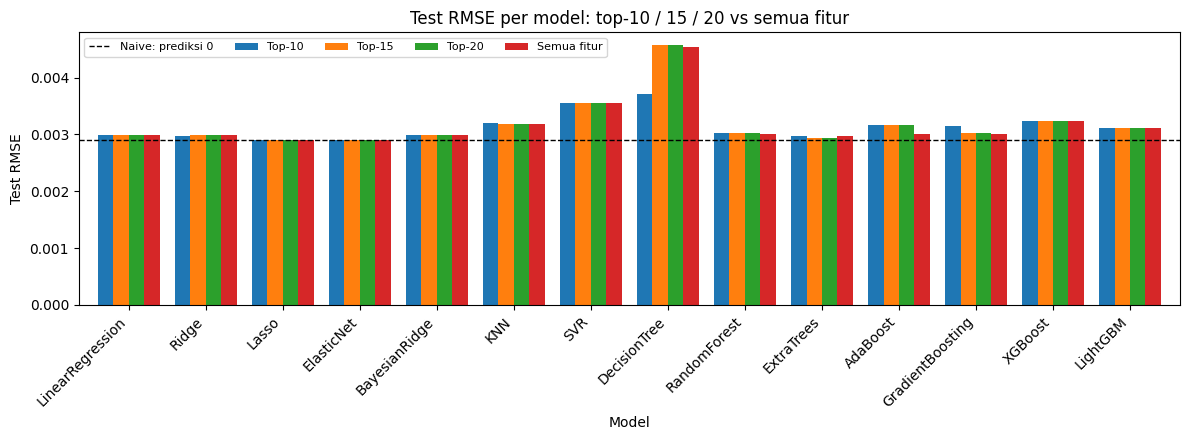

In [39]:
# ===== K terbaik per model (dipilih dari Val RMSE) + komposisi fitur yang terpilih =====
val_fs  = results_fs[results_fs['Split'] == 'Val']
test_fs = results_fs[results_fs['Split'] == 'Test'].set_index(['Model', 'K'])
best_k  = val_fs.loc[val_fs.groupby('Model')['RMSE'].idxmin()].set_index('Model')

tbl = pd.DataFrame({'Set fitur': best_k['Set fitur'], 'K terbaik': best_k['K'], 'Val RMSE': best_k['RMSE']})
for metric in METRICS:
    tbl[f'Test {metric}'] = [test_fs.loc[(m, k), metric] for m, k in zip(tbl.index, tbl['K terbaik'])]
tbl['Komposisi fitur'] = best_k['Komposisi']
tbl = tbl.reindex(list(MODELS)).sort_values('Val RMSE')
display(tbl)

# ===== Grafik: Test RMSE per model untuk tiap K =====
import matplotlib.pyplot as plt
pv = (results_fs[results_fs['Split'] == 'Test'].pivot(index='Model', columns='K', values='RMSE')[K_LABELS]
      .reindex(list(MODELS)))
ax = pv.plot(kind='bar', figsize=(12, 4.5), width=0.8)
ax.axhline(naive.query("Baseline == 'Prediksi 0' and Split == 'Test'")['RMSE'].iloc[0],
           color='k', ls='--', lw=1, label='Naive: prediksi 0')
ax.set_ylabel('Test RMSE'); ax.set_title('Test RMSE per model: top-10 / 15 / 20 vs semua fitur')
ax.legend(ncol=5, fontsize=8); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()